<a href="https://colab.research.google.com/github/Mr-Dipayan-Dey/CrimeDataAnalysis/blob/main/p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "crime_data_cleaned.csv" 
crime_df = pd.read_csv(file_path)

# Convert to datetime
crime_df['Date Reported'] = pd.to_datetime(crime_df['Date Reported'], errors='coerce')
crime_df['Date of Occurrence'] = pd.to_datetime(crime_df['Date of Occurrence'], errors='coerce')

# Preview
crime_df.head()


,Unnamed: 0,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed
0,0,1,2020-02-01 00:00:00,2020-01-01 00:00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No
1,1,2,2020-01-01 19:00:00,2020-01-01 01:00:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No
2,2,3,2020-02-01 05:00:00,2020-01-01 02:00:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No
3,3,4,2020-01-01 05:00:00,2020-01-01 03:00:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes
4,4,5,2020-01-01 21:00:00,2020-01-01 04:00:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes


/tmp/ipykernel_20086/3019826504.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x="City", y="Crimes", palette="coolwarm")


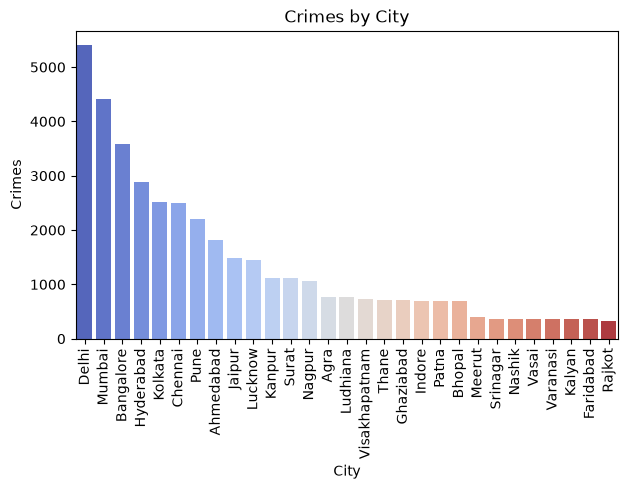

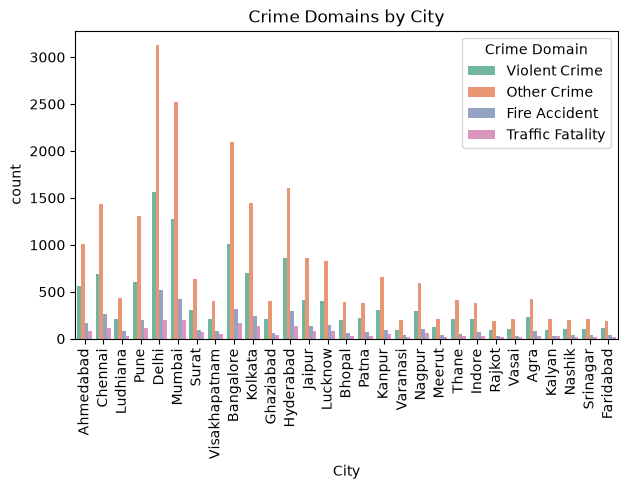

In [2]:
# Crimes by city
city_counts = crime_df['City'].value_counts().reset_index()
city_counts.columns = ["City", "Crimes"]

plt.figure(figsize=(7,4))
sns.barplot(data=city_counts, x="City", y="Crimes", palette="coolwarm")
plt.title("Crimes by City")
plt.xticks(rotation=90)
plt.show()

# Crime domains across cities
plt.figure(figsize=(7,4))
sns.countplot(data=crime_df, x="City", hue="Crime Domain", palette="Set2")
plt.title("Crime Domains by City")
plt.xticks(rotation=90)
plt.show()


/tmp/ipykernel_20086/560219162.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="viridis")


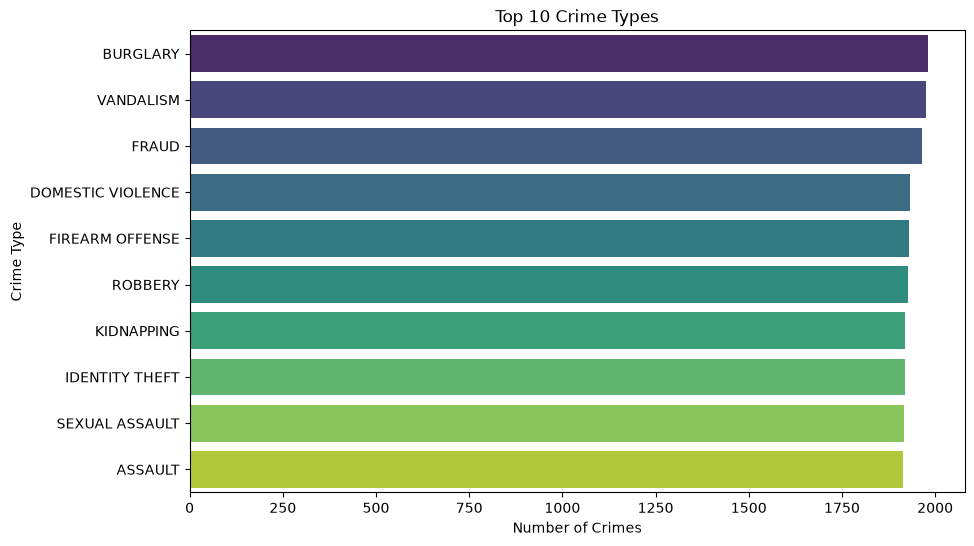

/tmp/ipykernel_20086/560219162.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weapons.values, y=top_weapons.index, palette="mako")


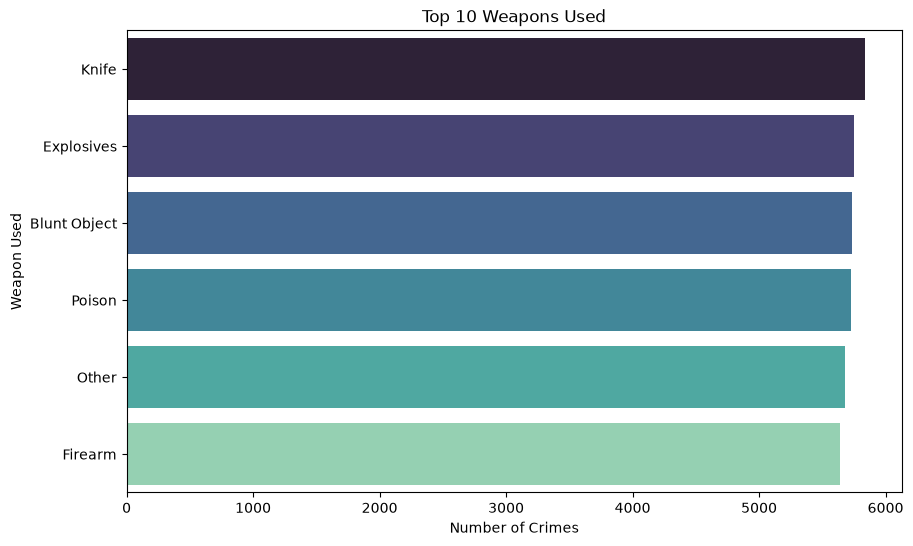

In [3]:
# Top Crime Descriptions
top_crimes = crime_df['Crime Description'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="viridis")
plt.title("Top 10 Crime Types")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.show()

# Weapons used
top_weapons = crime_df['Weapon Used'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_weapons.values, y=top_weapons.index, palette="mako")
plt.title("Top 10 Weapons Used")
plt.xlabel("Number of Crimes")
plt.ylabel("Weapon Used")
plt.show()


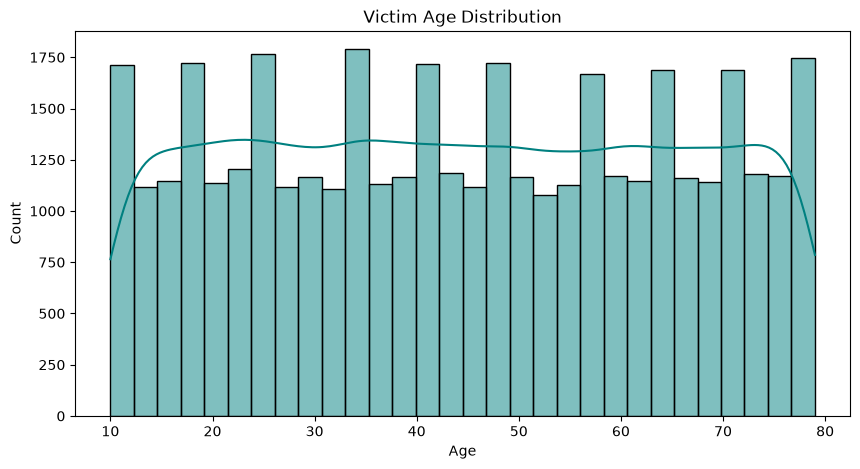

/tmp/ipykernel_20086/2539069088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=crime_df, x="Victim Gender", palette="pastel")


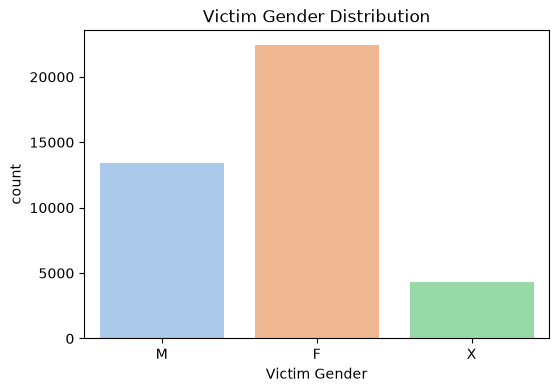

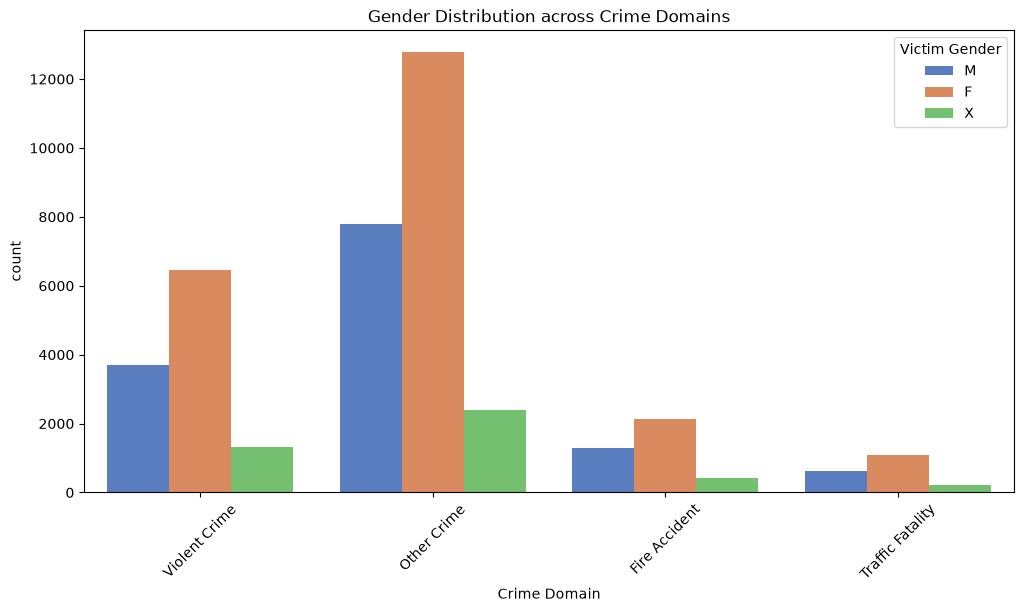

In [4]:
# Age distribution
plt.figure(figsize=(10,5))
sns.histplot(crime_df['Victim Age'], bins=30, kde=True, color="teal")
plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=crime_df, x="Victim Gender", palette="pastel")
plt.title("Victim Gender Distribution")
plt.show()

# Gender vs Crime Type
plt.figure(figsize=(12,6))
sns.countplot(data=crime_df, x="Crime Domain", hue="Victim Gender", palette="muted")
plt.title("Gender Distribution across Crime Domains")
plt.xticks(rotation=45)
plt.show()


Average Police Deployed per Case: 10.01


/tmp/ipykernel_20086/1372351158.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crime_df, x="Crime Domain", y="Police Deployed", palette="coolwarm")


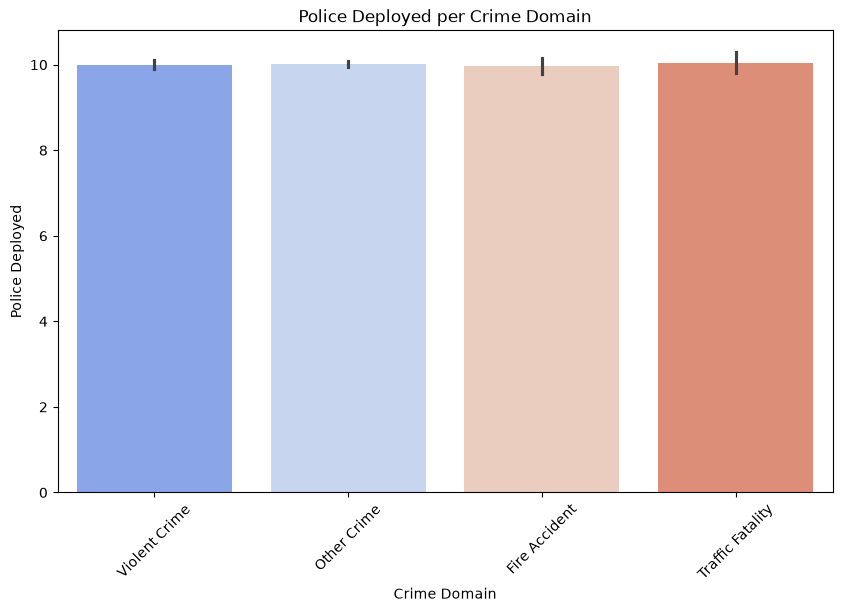

/tmp/ipykernel_20086/1372351158.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crime_df, x="Case Closed", y="Police Deployed", palette="Set1")


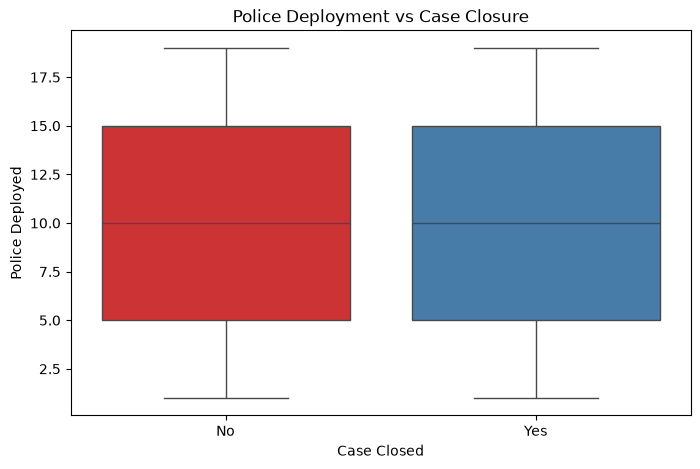

In [5]:
# Average police deployed per case
avg_police = crime_df['Police Deployed'].mean()
print(f"Average Police Deployed per Case: {avg_police:.2f}")

# Police deployed by crime domain
plt.figure(figsize=(10,6))
sns.barplot(data=crime_df, x="Crime Domain", y="Police Deployed", palette="coolwarm")
plt.title("Police Deployed per Crime Domain")
plt.xticks(rotation=45)
plt.show()

# Police deployed vs Case Closure
plt.figure(figsize=(8,5))
sns.boxplot(data=crime_df, x="Case Closed", y="Police Deployed", palette="Set1")
plt.title("Police Deployment vs Case Closure")
plt.show()


Case Closure Rates:
 Case Closed
No     50.044821
Yes    49.955179
Name: proportion, dtype: float64


/tmp/ipykernel_20086/2733901183.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=crime_df, x="Case Closed", palette="Set2")


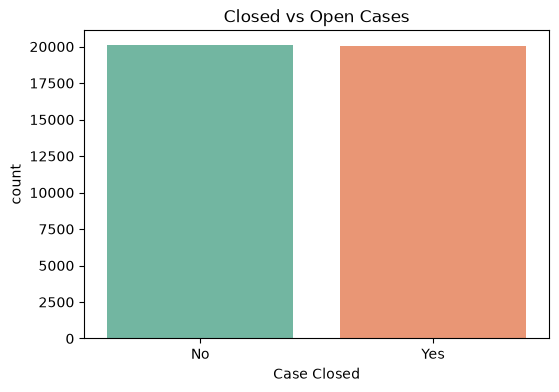

In [6]:
# % closed vs open
closure_rate = crime_df['Case Closed'].value_counts(normalize=True) * 100
print("Case Closure Rates:\n", closure_rate)

plt.figure(figsize=(6,4))
sns.countplot(data=crime_df, x="Case Closed", palette="Set2")
plt.title("Closed vs Open Cases")
plt.show()

# Time to close case (if we had closure date column)
if 'Date Case Closed' in crime_df.columns:
    crime_df['Date Case Closed'] = pd.to_datetime(crime_df['Date Case Closed'], errors='coerce')
    crime_df['Closure Days'] = (crime_df['Date Case Closed'] - crime_df['Date Reported']).dt.days

    plt.figure(figsize=(10,5))
    sns.histplot(crime_df['Closure Days'].dropna(), bins=30, kde=True, color="purple")
    plt.title("Distribution of Case Closure Time (Days)")
    plt.xlabel("Days to Close Case")
    plt.show()


/tmp/ipykernel_20086/2108096868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crime_df, x="Crime Domain", y="Victim Age", palette="Set3")


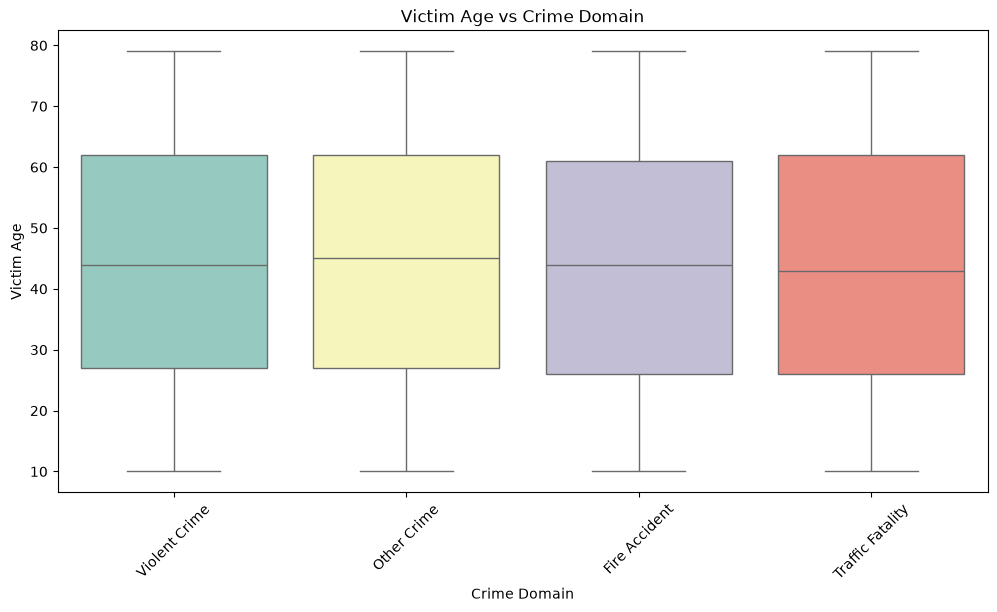

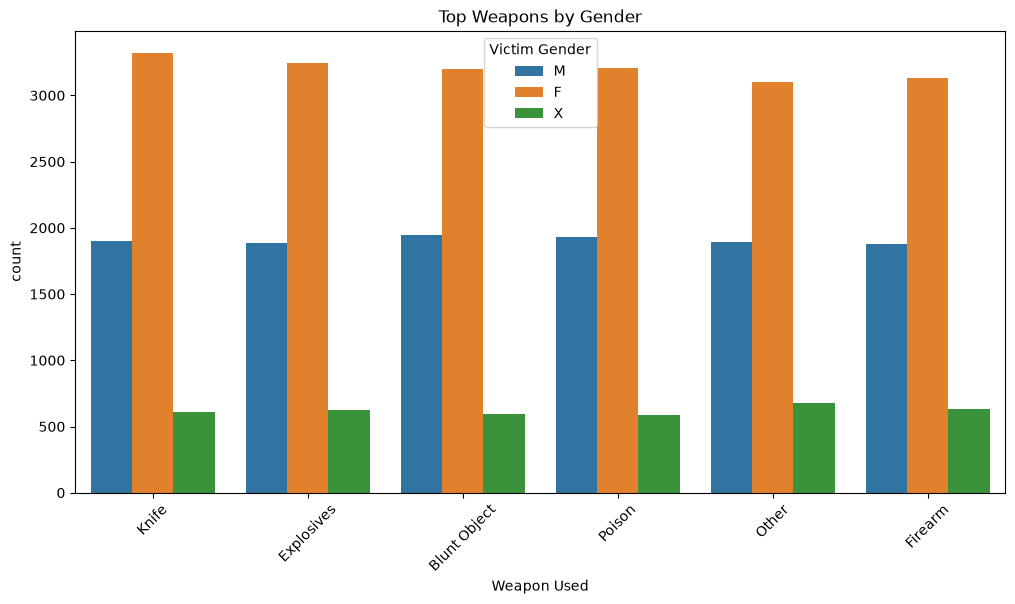

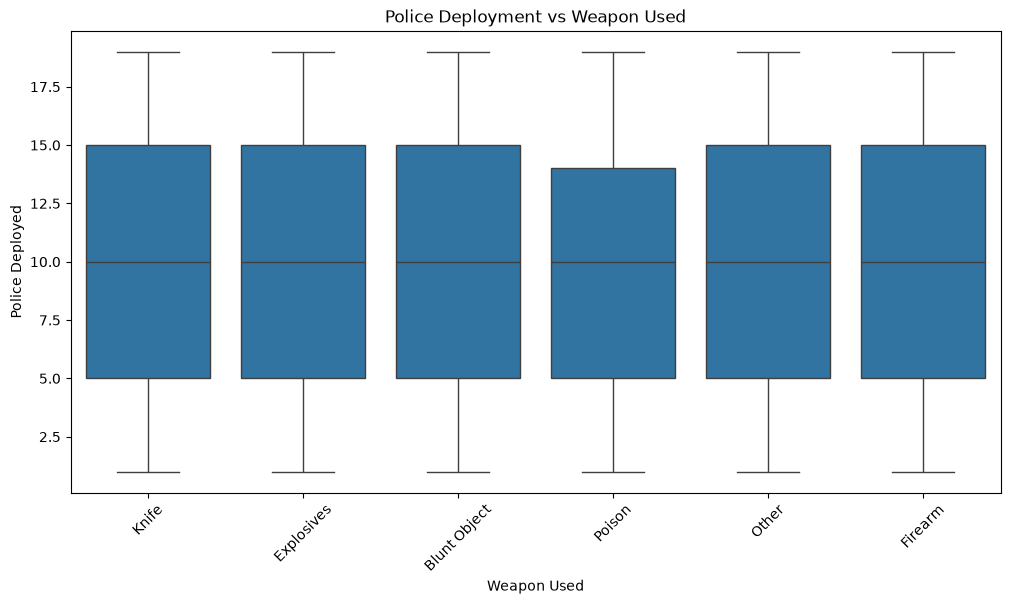

In [7]:
# Age vs Crime Domain
plt.figure(figsize=(12,6))
sns.boxplot(data=crime_df, x="Crime Domain", y="Victim Age", palette="Set3")
plt.title("Victim Age vs Crime Domain")
plt.xticks(rotation=45)
plt.show()

# Gender vs Weapon Used
plt.figure(figsize=(12,6))
sns.countplot(data=crime_df, x="Weapon Used", hue="Victim Gender", order=crime_df['Weapon Used'].value_counts().index[:10])
plt.title("Top Weapons by Gender")
plt.xticks(rotation=45)
plt.show()

# Police deployment vs weapon
plt.figure(figsize=(12,6))
sns.boxplot(data=crime_df, x="Weapon Used", y="Police Deployed", order=crime_df['Weapon Used'].value_counts().index[:10])
plt.title("Police Deployment vs Weapon Used")
plt.xticks(rotation=45)
plt.show()
